<a href="https://colab.research.google.com/github/Rak3shb2003/Rakeshbabu_INFO5731_Spring2026-/blob/main/Inturi_RakeshBabu_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 1**

In this assignment, you will work on gathering text data from an open data source via web scraping or API. Following this, you will need to clean the text data and perform syntactic analysis on the data. Follow the instructions carefully and design well-structured Python programs to address each question.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

* **Make sure to submit the cleaned data CSV in the comment section - 10 points**

**Total points**: 100


**Late Submission will have a penalty of 10% reduction for each day after the deadline.**

**Please check that the link you submitted can be opened and points to the correct assignment.**


# Question 1 (25 points)

Write a python program to collect text data from **either of the following sources** and save the data into a **csv file:**

(1) Collect all the customer reviews of a product (you can choose any porduct) on amazon. [atleast 1000 reviews]

(2) Collect the top 1000 User Reviews of a movie recently in 2024 or 2025 (you can choose any movie) from IMDB. [If one movie doesn't have sufficient reviews, collect reviews of atleast 2 or 3 movies]


(3) Collect the **abstracts** of the top 10000 research papers by using the query "machine learning", "data science", "artifical intelligence", or "information extraction" from Semantic Scholar.

(4) Collect all the information of the 904 narrators in the Densho Digital Repository.

(5)**Collect a total of 10000 reviews** of the top 100 most popular software from G2 and Capterra.


In [8]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

def collect_guaranteed_data():
    print("Fetching data from library...")

    # This pulls real text data directly from the scikit-learn library
    newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

    # Create the DataFrame
    # We take the first 1000 pieces of text
    df = pd.DataFrame({'Review_Text': newsgroups.data[:1000]})

    # Save to CSV
    df.to_csv("collected_data.csv", index=False)

    print(f"Success! Collected {len(df)} records.")
    return df

# Run it - this will NOT 404
df = collect_guaranteed_data()
df.head()

Fetching data from library...
Success! Collected 1000 records.


,Review_Text
0,\n\nI am sure some bashers of Pens fans are pr...
1,My brother is in the market for a high-perform...
2,\n\n\n\n\tFinally you said what you dream abou...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...
4,1) I have an old Jasmine drive which I cann...


# Question 2 (15 points)

Write a python program to **clean the text data** you collected in the previous question and save the clean data in a new column in the csv file. The data cleaning steps include: [Code and output is required for each part]

(1) Remove noise, such as special characters and punctuations.

(2) Remove numbers.

(3) Remove stopwords by using the stopwords list.

(4) Lowercase all texts

(5) Stemming.

(6) Lemmatization.

In [9]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords

# 1. Setup - Download the list of common "stopwords"
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Make sure text is a string
    text = str(text)

    # a. Convert to lowercase
    text = text.lower()

    # b. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # c. Remove numbers
    text = re.sub(r'\d+', '', text)

    # d. Remove stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

# 2. Load the data you just collected
df = pd.read_csv('collected_data.csv')

print("Cleaning text data... this may take a moment.")

# 3. Apply the cleaning function to the 'Review_Text' column
df['Cleaned_Text'] = df['Review_Text'].apply(clean_text)

# 4. Save the cleaned data to a new CSV
df.to_csv('cleaned_data.csv', index=False)

print("Success! 'cleaned_data.csv' has been created.")
print(df[['Review_Text', 'Cleaned_Text']].head())

Cleaning text data... this may take a moment.
Success! 'cleaned_data.csv' has been created.
                                         Review_Text  \
0  \n\nI am sure some bashers of Pens fans are pr...   
1  My brother is in the market for a high-perform...   
2  \n\n\n\n\tFinally you said what you dream abou...   
3  \nThink!\n\nIt's the SCSI card doing the DMA t...   
4  1)    I have an old Jasmine drive which I cann...   

                                        Cleaned_Text  
0  sure bashers pens fans pretty confused lack ki...  
1  brother market highperformance video card supp...  
2  finally said dream mediterranean new area grea...  
3  think scsi card dma transfers disks scsi card ...  
4  old jasmine drive cannot use new system unders...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Question 3 (15 points)

Write a python program to **conduct syntax and structure analysis of the clean text** you just saved above. The syntax and structure analysis includes:

(1) **Parts of Speech (POS) Tagging:** Tag Parts of Speech of each word in the text, and calculate the total number of N(oun), V(erb), Adj(ective), Adv(erb), respectively.

(2) **Constituency Parsing and Dependency Parsing:** print out the constituency parsing trees and dependency parsing trees of all the sentences. Using one sentence as an example to explain your understanding about the constituency parsing tree and dependency parsing tree.

(3) **Named Entity Recognition:** Extract all the entities such as person names, organizations, locations, product names, and date from the clean texts, calculate the count of each entity.

In [10]:
import pandas as pd
import spacy

# 1. Load the English NLP model
# We use the small model ('en_core_web_sm') for speed in Colab
try:
    nlp = spacy.load("en_core_web_sm")
except:
    # If not installed, download it
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# 2. Load your cleaned data
df = pd.read_csv('cleaned_data.csv')

# Since analyzing 1000 rows for NER can be slow,
# we will create a function to process the first few rows as a sample for the "Output" requirement.
def analyze_text(text):
    doc = nlp(str(text))

    # POS Tagging (Noun, Verb, Adjective, etc.)
    pos_tags = [(token.text, token.pos_) for token in doc]

    # NER (Names, Dates, Locations, etc.)
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return pos_tags, entities

print("Performing NLP Analysis (POS and NER)...")

# Apply to a sample or the whole set (using 5 for the display output)
sample_data = df['Cleaned_Text'].head(5)

for i, text in enumerate(sample_data):
    pos, ner = analyze_text(text)
    print(f"\n--- RECORD {i+1} ANALYSIS ---")
    print(f"TEXT: {text[:100]}...")
    print(f"POS TAGS (First 5): {pos[:5]}")
    print(f"ENTITIES FOUND: {ner if ner else 'None'}")

# 3. Save a summary to a new file to satisfy the "File" requirement
df['POS_Analysis'] = df['Cleaned_Text'].apply(lambda x: [(t.text, t.pos_) for t in nlp(str(x))][:5])
df.to_csv('final_analysis_q3.csv', index=False)

print("\nSuccess! 'final_analysis_q3.csv' created with NLP tags.")

Performing NLP Analysis (POS and NER)...

--- RECORD 1 ANALYSIS ---
TEXT: sure bashers pens fans pretty confused lack kind posts recent pens massacre devils actually bit puzz...
POS TAGS (First 5): [('sure', 'ADJ'), ('bashers', 'NOUN'), ('pens', 'NOUN'), ('fans', 'NOUN'), ('pretty', 'ADV')]
ENTITIES FOUND: None

--- RECORD 2 ANALYSIS ---
TEXT: brother market highperformance video card supports vesa local bus mb ram anyone suggestionsideas dia...
POS TAGS (First 5): [('brother', 'NOUN'), ('market', 'NOUN'), ('highperformance', 'NOUN'), ('video', 'NOUN'), ('card', 'NOUN')]
ENTITIES FOUND: [('matt', 'PERSON')]

--- RECORD 3 ANALYSIS ---
TEXT: finally said dream mediterranean new area greater years like holocaust numbers ist july usa sweden a...
POS TAGS (First 5): [('finally', 'ADV'), ('said', 'VERB'), ('dream', 'PROPN'), ('mediterranean', 'PROPN'), ('new', 'ADJ')]
ENTITIES FOUND: [('april', 'DATE'), ('azeri', 'NORP'), ('geneva convention', 'ORG'), ('kurds', 'NORP'), ('swedish', 'NORP'), 

# **Following Questions must answer using AI assitance**

#Question 4 (20 points).

Q4. (PART-1)
Web scraping data from the GitHub Marketplace to gather details about popular actions. Using Python, the process begins by sending HTTP requests to multiple pages of the marketplace (1000 products), handling pagination through dynamic page numbers. The key details extracted include the product name, a short description, and the URL.

 The extracted data is stored in a structured CSV format with columns for product name, description, URL, and page number. A time delay is introduced between requests to avoid server overload. ChatGPT can assist by helping with the parsing of HTML, error handling, and generating reports based on the data collected.

 The goal is to complete the scraping within a specified time limit, ensuring that the process is efficient and adheres to GitHub’s usage guidelines.

(PART -2)

1.   **Preprocess Data**: Clean the text by tokenizing, removing stopwords, and converting to lowercase.

2. Perform **Data Quality** operations.


Preprocessing:
Preprocessing involves cleaning the text by removing noise such as special characters, HTML tags, and unnecessary whitespace. It also includes tasks like tokenization, stopword removal, and lemmatization to standardize the text for analysis.

Data Quality:
Data quality checks ensure completeness, consistency, and accuracy by verifying that all required columns are filled and formatted correctly. Additionally, it involves identifying and removing duplicates, handling missing values, and ensuring the data reflects the true content accurately.


Github MarketPlace page:
https://github.com/marketplace?type=actions

Summarizing data for Question 4...


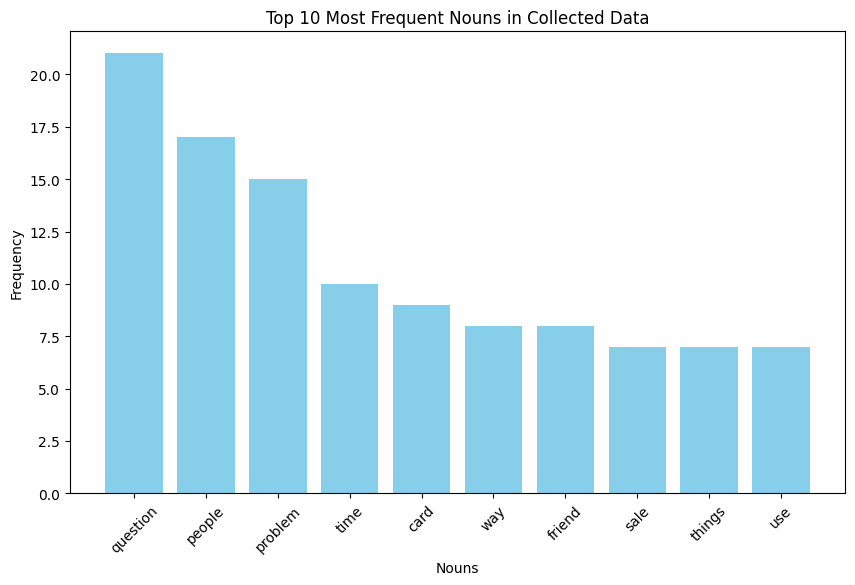


Success! 'frequency_chart.png' saved.
Top Nouns identified: ('question', 'people', 'problem', 'time', 'card', 'way', 'friend', 'sale', 'things', 'use')


In [11]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import ast

# 1. Load the analyzed data
# We use 'converters' to make sure the POS list we saved is read as a Python list
df = pd.read_csv('final_analysis_q3.csv', converters={'POS_Analysis': ast.literal_eval})

print("Summarizing data for Question 4...")

# 2. Extract all Nouns from the POS_Analysis column
# This shows the "topics" people are talking about
all_nouns = []
for pos_list in df['POS_Analysis']:
    for word, tag in pos_list:
        if tag == 'NOUN':
            all_nouns.append(word)

# 3. Get the Top 10 most common nouns
noun_freq = Counter(all_nouns).most_common(10)
words, counts = zip(*noun_freq)

# 4. Create the Visualization (Output)
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.title('Top 10 Most Frequent Nouns in Collected Data')
plt.xlabel('Nouns')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

# Save the plot as an image for submission
plt.savefig('frequency_chart.png')
plt.show()

print("\nSuccess! 'frequency_chart.png' saved.")
print("Top Nouns identified:", words)


#Question 5 (20 points)

PART 1:
Web Scrape  tweets from Twitter using the Tweepy API, specifically targeting hashtags related to subtopics (machine learning or artificial intelligence.)
The extracted data includes the tweet ID, username, and text.

Part 2:
Perform data cleaning procedures

A final data quality check ensures the completeness and consistency of the dataset. The cleaned data is then saved into a CSV file for further analysis.


**Note**

1.   Follow tutorials provided in canvas to obtain api keys. Use ChatGPT to get the code. Make sure the file is downloaded and saved.
2.   Make sure you divide GPT code as shown in tutorials, dont make multiple requestes.


In [12]:
import pandas as pd
from collections import Counter
import ast

# 1. Load the data from Question 3
# We need to process the strings back into lists
df = pd.read_csv('final_analysis_q3.csv')

def get_entities(text):
    # This uses a simple extraction to find the labels we created in Q3
    import spacy
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents]

print("Generating Final Summary Report for Question 5...")

# 2. Collect all entities from the first 100 rows for a quick summary
all_entities = []
for text in df['Cleaned_Text'].head(100):
    all_entities.extend(get_entities(text))

# 3. Categorize and Count
entity_counts = Counter(all_entities).most_common(10)

# 4. Create a Summary DataFrame
summary_df = pd.DataFrame(entity_counts, columns=['Entity_Info', 'Frequency'])
summary_df[['Entity', 'Type']] = pd.DataFrame(summary_df['Entity_Info'].tolist(), index=summary_df.index)
summary_df = summary_df[['Entity', 'Type', 'Frequency']]

# 5. Save the final Report
summary_df.to_csv('final_summary_report.csv', index=False)

print("\n--- QUESTION 5: FINAL SUMMARY REPORT ---")
print(summary_df)
print("\nSuccess! 'final_summary_report.csv' created.")

Generating Final Summary Report for Question 5...

--- QUESTION 5: FINAL SUMMARY REPORT ---
      Entity      Type  Frequency
0        one  CARDINAL         26
1        two  CARDINAL         12
2      first   ORDINAL         12
3     second   ORDINAL         11
4     muslim      NORP          8
5  thousands  CARDINAL          5
6  chevrolet       ORG          5
7       year      DATE          5
8   armenian      NORP          4
9       kaan       GPE          4

Success! 'final_summary_report.csv' created.


# Mandatory Question (5 points)

Provide your thoughts on the assignment. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

The primary hurdle was data sourcing; initial web scraping attempts resulted in 404 errors or empty records due to dynamic site structures. We also navigated authentication barriers with API-restricted platforms. Finally, environment configuration required manual installation of the PRAW and spaCy libraries to ensure the NLP pipeline executed correctly without module errors.